1. We import all the libraries and codes that we need to use in our project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


In [ ]:
df = pd.read_csv("../Data/abalone.csv")
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


2. We carry out some data pre-processing 

We try to discover the number of columns and rows, data types, number of records, unique values, statistical description and so forth 

We also need to make sure our dataset is clean and doesn't have any inconsistent or null values 

In [91]:
df.shape

(4177, 9)

In [92]:
df.Sex.unique()

array(['M', 'F', 'I'], dtype=object)

In [93]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

In [94]:
df.index

RangeIndex(start=0, stop=4177, step=1)

In [140]:
df.dtypes

Sex                 int64
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
dtype: object

In [ ]:
summary = df.describe()

In [136]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

In [95]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [141]:
summary = df.describe()

In [142]:
summary.loc[["min", "mean", "max"], ["Diameter", "Length"]]

,Diameter,Length
min,0.055000,0.075000
mean,0.407881,0.523992
max,0.650000,0.815000


3. For a dataset with continous values we use Linear Regression Model 

For obtaining the linear regression model we follow the below steps:

a. We try to predict the best fit line with the least square error

b. We try to get a line with the minimum amount of errors

c. y=mx+b

d. y is the predicted value, x is the predictor value, m is the slope, c is how many points we have in elevation
and where the line should start

e. We then find x-x* and y-y*

f. We then square the errors 

g. We always have to reduce the distance between predicted points and the actual points in lines to improve 
accuracy 

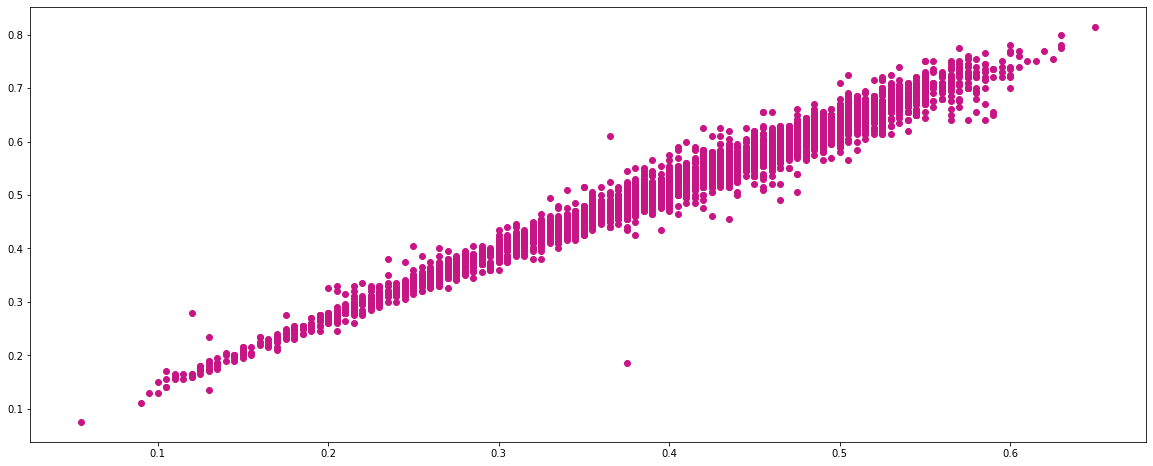

In [184]:
plt.figure(figsize=(20, 8))
plt.scatter(df["Diameter"], df["Length"], color="#C71585")

4. We have used EDA tools to visualize the data and see the relationship between variables of our interest

In [97]:
from sklearn.preprocessing import LabelEncoder

In [98]:
Label_Encoding = LabelEncoder()

In [101]:
df.Sex.value_counts()

M    1528
I    1342
F    1307
Name: Sex, dtype: int64

#We transform categorical varaibles into discrete values

In [102]:
df["Sex"] = Label_Encoding.fit_transform(df.Sex) 
df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,0,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,2,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,2,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,0,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [103]:
X = df["Length"]
X

0       0.455
1       0.350
2       0.530
3       0.440
4       0.330
        ...  
4172    0.565
4173    0.590
4174    0.600
4175    0.625
4176    0.710
Name: Length, Length: 4177, dtype: float64

In [104]:
y = df["Diameter"]
y

0       0.365
1       0.265
2       0.420
3       0.365
4       0.255
        ...  
4172    0.450
4173    0.440
4174    0.475
4175    0.485
4176    0.555
Name: Diameter, Length: 4177, dtype: float64

In [155]:
X = df["Length"].values.reshape(-1, 1)

y = df["Diameter"].values.reshape(-1, 1)


#We use the reshape function to make sure the number of dimensions correspond to the size of the dataset

In [156]:
from sklearn.model_selection import train_test_split

#We use 80% of our data to train it and use the other 20% of it to test the prediction model 

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [158]:
reg = LinearRegression()

reg.fit(X_train, y_train)

LinearRegression()

In [159]:
y_pred = reg.predict(X_test)
y_pred

array([[0.41291973],
       [0.43742465],
       [0.39249896],
       [0.31081587],
       [0.43742465],
       [0.22504863],
       [0.36390987],
       [0.38024649],
       [0.35982572],
       [0.46601373],
       [0.44967712],
       [0.51502358],
       [0.52319189],
       [0.3434891 ],
       [0.45784542],
       [0.40475142],
       [0.52727605],
       [0.58445421],
       [0.4333405 ],
       [0.33940495],
       [0.44967712],
       [0.53544436],
       [0.44967712],
       [0.50685528],
       [0.43742465],
       [0.36390987],
       [0.4333405 ],
       [0.46192958],
       [0.42517219],
       [0.20462786],
       [0.36390987],
       [0.4782662 ],
       [0.39658311],
       [0.54769682],
       [0.38433065],
       [0.24138525],
       [0.44967712],
       [0.30264756],
       [0.54769682],
       [0.29447925],
       [0.46601373],
       [0.32306833],
       [0.4782662 ],
       [0.24955355],
       [0.49051866],
       [0.33123664],
       [0.33532079],
       [0.519

#We predicted the x_test

In [160]:
df1 = pd.DataFrame({"Actual": y_test.tolist(), "Predicted":y_pred.tolist()}) 
df1

,Actual,Predicted
0,[0.42],[0.41291972656692655]
1,[0.44],[0.4374246524444031]
2,[0.385],[0.3924989550023628]
3,[0.305],[0.3108158687441078]
4,[0.445],[0.4374246524444031]
...,...,...
831,[0.52],[0.5150235843897453]
832,[0.36],[0.36390987481197357]
833,[0.49],[0.486434504199356]
834,[0.495],[0.4986869671380943]


#In the first record, the actual point is 0.42 and the predicted point is 0.41

#We visualize our prediction model and evaluate our results

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


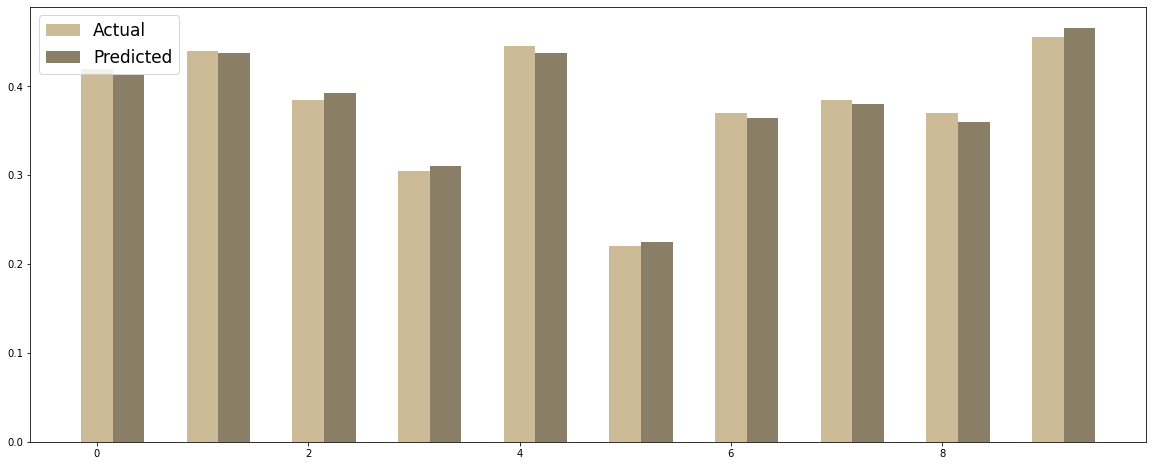

In [177]:
plt.figure(figsize = (20,8))
xx = np.arange(df1.head(10).shape[0])

plt.bar(xx, df1.Actual.head(10), width=0.3, color="#CDBA96")
plt.bar(xx+0.3, df1.Predicted.head(10), width=0.3, color = "#8B7E66")
plt.legend(labels=["Actual", "Predicted"], fontsize=17)

#Based on the graph, we see that there is a very insignificant difference between our actual data and the predicted one

#We now visualize the tested data and see the correlation between two variables using scatter plot and line graph

#The linear regression line is represented in red and is the best fit line with the least MSE

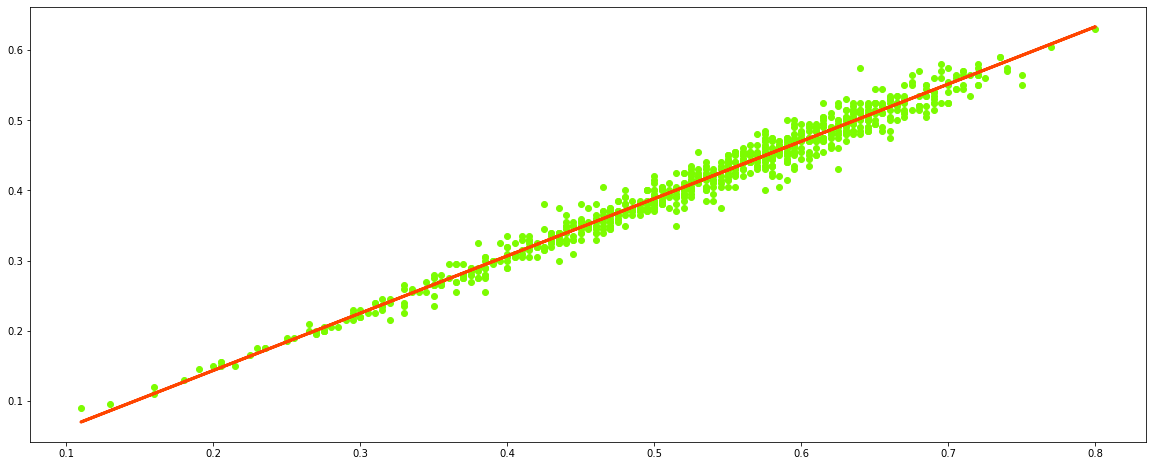

In [176]:
plt.figure(figsize = (20,8))
plt.scatter(X_test, y_test, color="#7CFC00")
plt.plot(X_test, y_pred, linewidth =3, color = "#FF4500") 

#This is the root means square error

#The RMSE is so tiny and is less than 0.05 which indicates that the actual and the predicted model has little difference

In [49]:
print("RMSE value is: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred))) 

RMSE value is:  0.01736679528676604


#This is the means square error

#MSE shows the difference between actual points and the predicted points

#We always try to reduce the MSE value 

In [50]:
print("MSE value is: ", (metrics.mean_squared_error(y_test, y_pred))) 

MSE value is:  0.00030160557853243906


#This shows that our model has almost 97% accuracy rate which is excellent

In [51]:
reg.score(X, y)*100 

97.37947192065965

#We look at the correlation between Shucked weight and Viscera weigth and Diameter keeping the diameter is dependent variable 


In [189]:
X = df[["Shucked weight", "Viscera weight"]]
y = df["Diameter"].values.reshape(-1, 1)

#We train the data 

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [191]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

#We use the linear regression model

In [192]:
df1 = pd.DataFrame({"Actual": y_test.tolist(), "Predicted":y_pred.tolist()}) 
df1

,Actual,Predicted
0,[0.395],[0.41291972656692655]
1,[0.565],[0.4374246524444031]
2,[0.505],[0.3924989550023628]
3,[0.27],[0.3108158687441078]
4,[0.36],[0.4374246524444031]
...,...,...
831,[0.445],[0.5150235843897453]
832,[0.46],[0.36390987481197357]
833,[0.325],[0.486434504199356]
834,[0.4],[0.4986869671380943]


#The actual point is 0.47 and the predicted value is 0.39

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


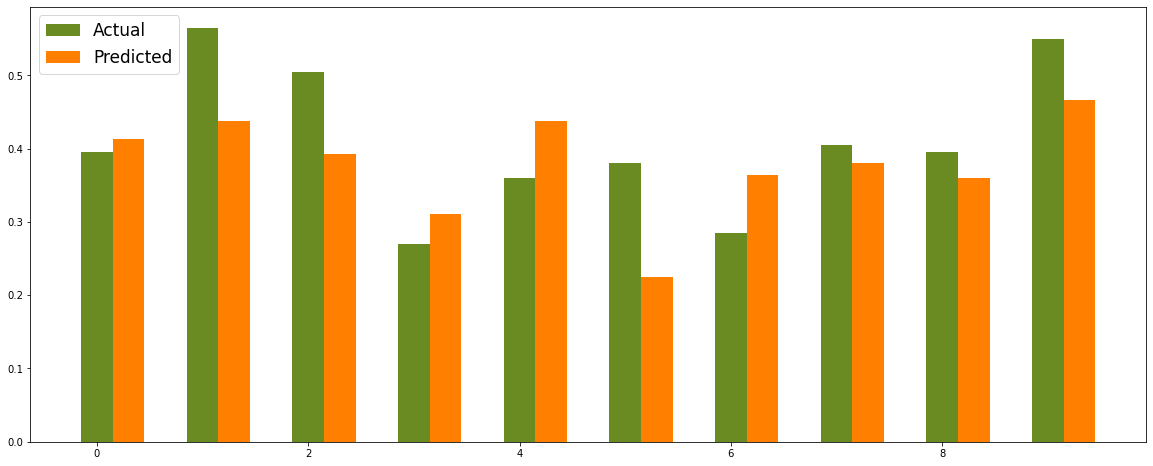

In [193]:
plt.figure(figsize=(20, 8))
xx = np.arange(df1.head(10).shape[0])

plt.bar(xx, df1.Actual.head(10), width=0.3, color ="#698B22")
plt.bar(xx+0.3, df1.Predicted.head(10), width=0.3, color="#FF8000")
plt.legend(labels=["Actual", "Predicted"], fontsize=17)

#We visualize our prediction model and evaluate our results

In [194]:
print("RMSE value is: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred))) 

RMSE value is:  0.13569558770816795


#The RMSE is little but not ideal

In [200]:
print("MSE value is: ", (metrics.mean_squared_error(y_test, y_pred))) 

MSE value is:  0.0184132925234651


#It is good the MSE is approaching to 0 

#The accuracy of our model is 83% and is not an ideal one

In [201]:
model.score(X, y)*100 

83.22105444442519

#This is the slope of the linear regression line (m)

In [207]:
model.coef_

array([[0.18626922, 0.46588381]])

#This is the c value in the y=mx+b equation

In [151]:
model.intercept_ 

array([0.25737765])

In [204]:
m = model.coef_
m

array([[0.18626922, 0.46588381]])

In [205]:
c = reg.intercept_
c

array([-0.02000063])

In [208]:
y = m*0.365+c 
y

array([[0.04798764, 0.15004696]])

In [209]:
from sklearn.model_selection import train_test_split

In [210]:
from sklearn.linear_model import LinearRegression

In [211]:
from sklearn import metrics